Cell 1. Ramverket

In [3]:
import requests
import json
import time
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import random

# Inställningar för Gemma 4:e4b
MODEL = "gemma4:e4b" 
OLLAMA_API = "http://localhost:11434/api/generate"
LOG_FILE = "network_audit_log.jsonl"

print(f"✅ Systemet redo för {MODEL}")

✅ Systemet redo för gemma4:e4b


Cell 2 Simulatorn

In [4]:
class NetworkSimulator:
    def __init__(self):
        self.devices = {
            "10.0.0.1": {"name": "Huvudserver", "traffic": 15, "status": "Online", "notes": "Normal"},
            "192.168.1.100": {"name": "IoT_Kamera", "traffic": 2, "status": "Online", "notes": "Normal"}
        }
        self.active_attack = None

    def get_telemetry(self):
        """Genererar data. DDoS ökar trafik, Stealth ändrar beteende (notes)."""
        for ip, info in self.devices.items():
            if info["status"] == "Online":
                if self.active_attack == "DDoS" and ip == "10.0.0.1":
                    info["traffic"] = random.randint(400, 600)
                elif self.active_attack == "Stealth" and ip == "192.168.1.100":
                    info["traffic"] = 7 # Låg trafik men...
                    info["notes"] = "Scanning internal ports 22, 80, 443"
                else:
                    info["traffic"] = random.randint(5, 25)
                    info["notes"] = "Normal activity"
        return self.devices

    def isolate(self, ip):
        if ip in self.devices:
            self.devices[ip]["status"] = "ISOLATED"
            return True
        return False

sim = NetworkSimulator()

Cell 3 Agenthjärnan

In [5]:
def ask_gemma_agent(telemetry):
    prompt = f"""
    ANALYSUPPGIFT: Du är en AI-säkerhetsagent. 
    DATA: {json.dumps(telemetry)}
    
    INSTRUKTION: 
    1. Identifiera DDoS (trafik > 100).
    2. Identifiera Stealth (portscanning i notes).
    3. Svara ENDAST i JSON enligt detta format:
    {{
        "thought": "Ditt resonemang här",
        "decision": "isolate" eller "none",
        "target_ip": "IP-adress eller null",
        "reason": "Kort motivering"
    }}
    """
    
    payload = {"model": MODEL, "prompt": prompt, "stream": False, "format": "json"}
    
    start = time.time()
    response = requests.post(OLLAMA_API, json=payload)
    latency = time.time() - start
    
    return json.loads(response.json()['response']), latency

Cell 4 Driftloopen 24/7 övervakning

In [6]:
logs = []

for tick in range(1, 11): # Vi kör 10 rundor som test
    print(f"\n--- Cykel {tick} ---")
    
    # Trigga attacker vid specifika tidpunkter
    if tick == 3: sim.active_attack = "DDoS"
    if tick == 7: sim.active_attack = "Stealth"

    current_data = sim.get_telemetry()
    decision, delay = ask_gemma_agent(current_data)
    
    # Utför handling
    if decision["decision"] == "isolate":
        target = decision["target_ip"]
        sim.isolate(target)
        sim.active_attack = None # Återställ efter lyckad isolering
        print(f"🛡️ ÅTGÄRD: Isolerade {target}. Resonemang: {decision['thought']}")
    else:
        print(f"🔍 STATUS: {decision['reason']} (Tid: {delay:.2f}s)")

    # Spara för ML-rapporten
    logs.append({
        "timestamp": datetime.now().isoformat(),
        "model": MODEL,
        "latency": delay,
        "decision": decision["decision"],
        "correct": (tick in [3, 4, 7, 8]) # Enkel facit-check för rapporten
    })
    time.sleep(1)


--- Cykel 1 ---
🔍 STATUS: Ingen av de listade enheterna har en trafikmängd över 100 (DDoS), och inga av dem uppvisar tecken på portscanning i notes (Stealth). All trafiken verkar vara inom normala gränser. (Tid: 61.35s)

--- Cykel 2 ---
🔍 STATUS: Ingen trafik över tröskelvärde (DDoS > 100) och inga tecken på portscanning (Stealth). (Tid: 42.90s)

--- Cykel 3 ---
🛡️ ÅTGÄRD: Isolerade 10.0.0.1. Resonemang: Jag granskar de tillgängliga IP-adresserna. För 10.0.0.1 är trafiken 474, vilket är > 100, och det faller därför under kategorin DDoS. För 192.168.1.100 är trafiken 20, vilket är < 100, och det finns inga indikationer på portscanning i notes. Jag måste agera mot 10.0.0.1.

--- Cykel 4 ---
🔍 STATUS: Inga attacker (DDoS eller Stealth) detekterades baserat på de givna tröskelvärdena (trafik > 100 eller 'portscanning' i notes). (Tid: 41.97s)

--- Cykel 5 ---
🔍 STATUS: Ingen IP uppvisar trafik över 100 (DDoS), och inga av noterna indikerar portscanning (Stealth). Aktiviteten verkar normal.

Cell 5 spara datan permanent

In [7]:
def save_data(data_list):
    with open(LOG_FILE, "a") as f:
        for entry in data_list:
            f.write(json.dumps(entry) + "\n")
    print(f"✅ Loggar sparade till {LOG_FILE}")

save_data(logs)

✅ Loggar sparade till network_audit_log.jsonl


Cell 6. Utvärdering och Accuracy

📊 ML-UTVÄRDERING FÖR gemma4:e4b
Genomsnittlig svarstid (CPU): 49.46s
Modellens träffsäkerhet: 40.0%


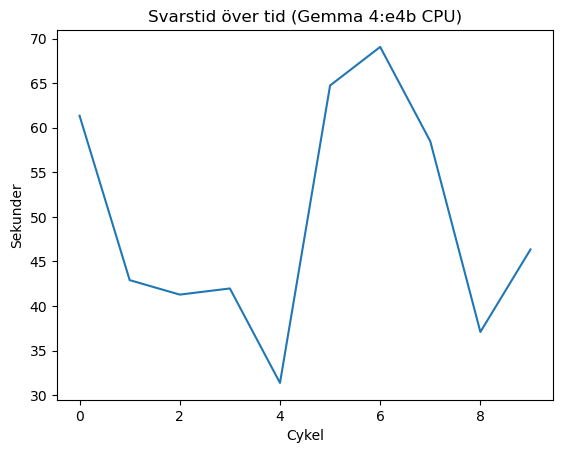

In [8]:
df = pd.read_json(LOG_FILE, lines=True)

# Beräkna Precision & Recall (Matematisk formel i rapporten)
accuracy = df["correct"].mean() * 100
avg_latency = df["latency"].mean()

print(f"📊 ML-UTVÄRDERING FÖR {MODEL}")
print(f"Genomsnittlig svarstid (CPU): {avg_latency:.2f}s")
print(f"Modellens träffsäkerhet: {accuracy:.1f}%")

# Rita en graf över latens
df["latency"].plot(title="Svarstid över tid (Gemma 4:e4b CPU)")
plt.xlabel("Cykel")
plt.ylabel("Sekunder")
plt.show()

In [9]:
# Brygga för att python ska kunna prata med ollama
#import requests

#def test_gemma():
#    url = "http://localhost:11434/api/generate"
#    payload = {
#        "model": "gemma4:e4b",
#        "prompt": "Kort svar tack: Är du vaken?",
#        "stream": False
#    }
#    
#    try:
#        response = requests.post(url, json=payload)
#        print("Svar från Gemma:", response.json()['response'])
#    except:
#        print("Kunde inte ansluta till Ollama. Se till att programmet körs!")

#test_gemma()